In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../Dataset/SampleSuperstore.csv")

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [5]:
df.shape

(9994, 13)

In [6]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [7]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [9]:
df["Sales"].sum()

np.float64(2297200.8603)

In [10]:
df["Profit"].sum()

np.float64(286397.0217)

In [11]:
df["Quantity"].sum()

np.int64(37873)

In [12]:
sales_by_category=df.groupby("Category")["Sales"].sum()
print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


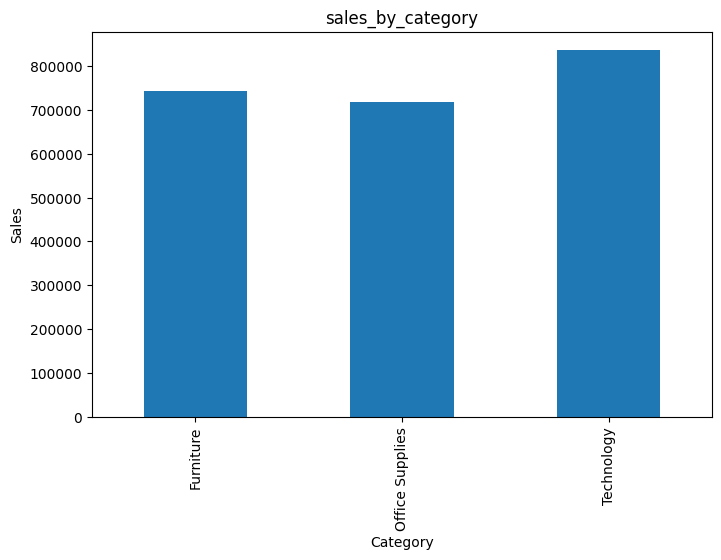

In [13]:
sales_by_category.plot(kind="bar",figsize=(8,5))
plt.title("sales_by_category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()


In [14]:
profit_by_category=df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(profit_by_category)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


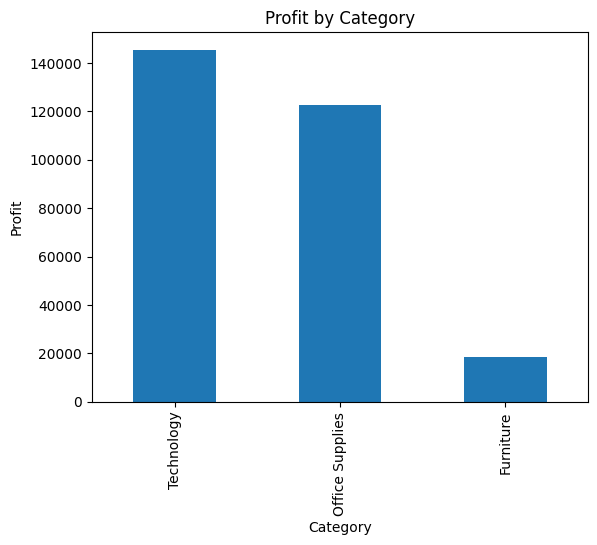

In [15]:
profit_by_category.plot(kind="bar", title="Profit by Category")
plt.ylabel("Profit")
plt.xlabel("Category")
plt.show()

In [16]:
sales_by_region=df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(sales_by_region)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


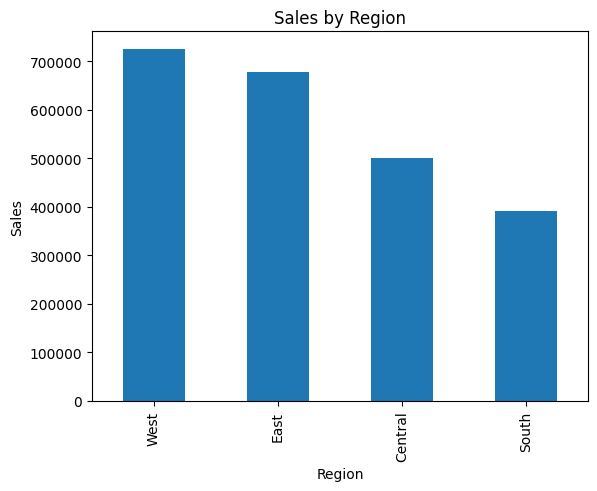

In [17]:
sales_by_region.plot(kind="bar",title="Sales by Region")
plt.ylabel("Sales")
plt.show()

In [18]:
def discount_group(x):
    if x == 0:
        return "No Discount"
    elif x <= 0.2:
        return "Low Discount"
    elif x <= 0.5:
        return "Medium Discount"
    else:
        return "High Discount"
df["Discount_Group"]=df["Discount"].apply(discount_group)

In [19]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Discount_Group'],
      dtype='str')

In [20]:
df.groupby("Discount_Group")[["Sales","Profit"]].mean()

,Sales,Profit
Discount_Group,,
High Discount,75.033572,-89.438144
Low Discount,222.593279,26.501571
Medium Discount,555.943039,-109.528873
No Discount,226.742074,66.900292


In [21]:
top_State=df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)
print(top_State)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


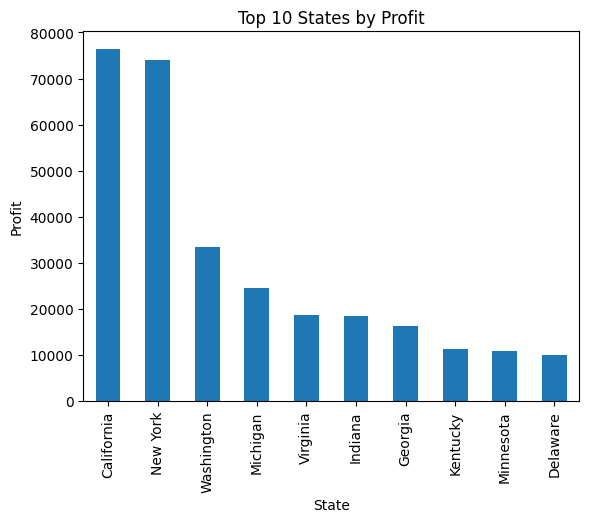

In [22]:
top_State.plot(kind="bar", title="Top 10 States by Profit")
plt.ylabel("Profit")
plt.show()

In [23]:
segment=df.groupby("Segment")["Profit"].sum()
print(segment)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


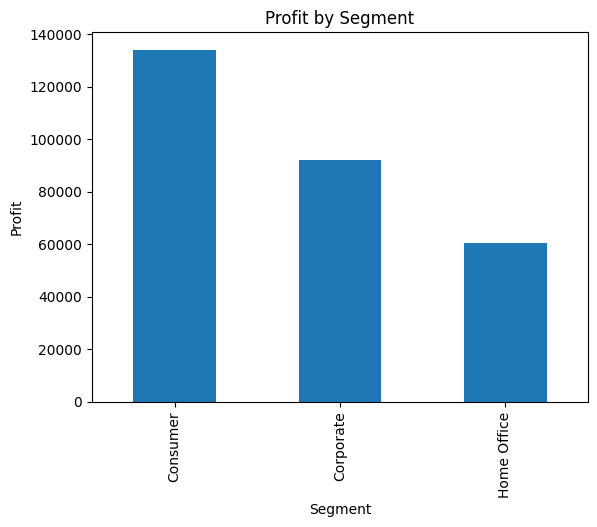

In [24]:
segment.plot(kind="bar", title="Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.show()

In [25]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_cities)

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


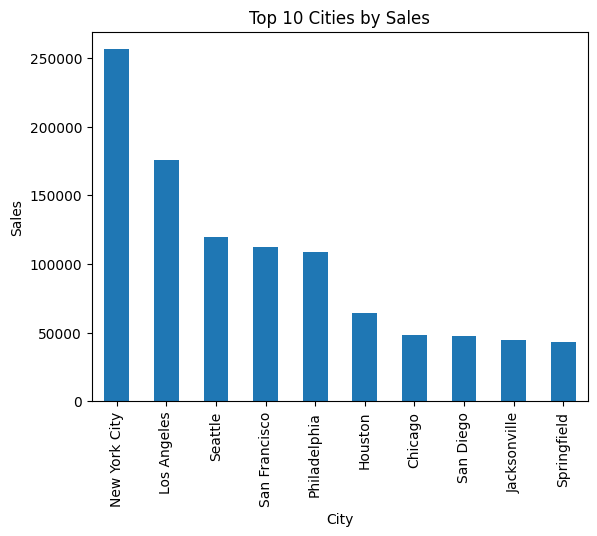

In [26]:
top_cities.plot(kind="bar", title="Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.show()

In [27]:
quantity = df.groupby("Category")["Quantity"].sum()

print(quantity)

Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64


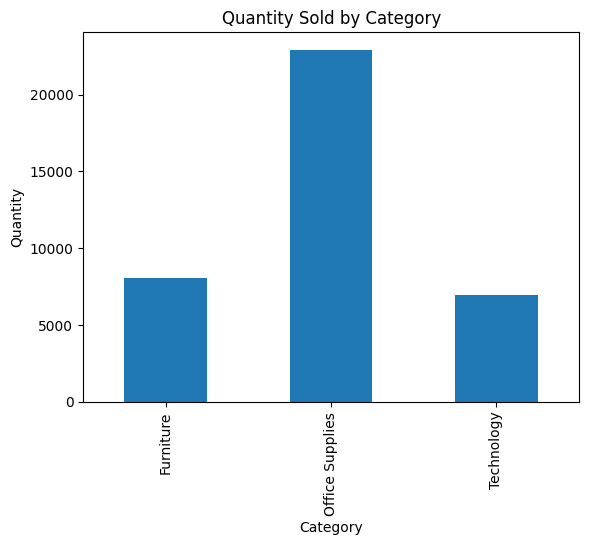

In [28]:
quantity.plot(kind="bar", title="Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.show()

In [29]:
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

print(sub_profit)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


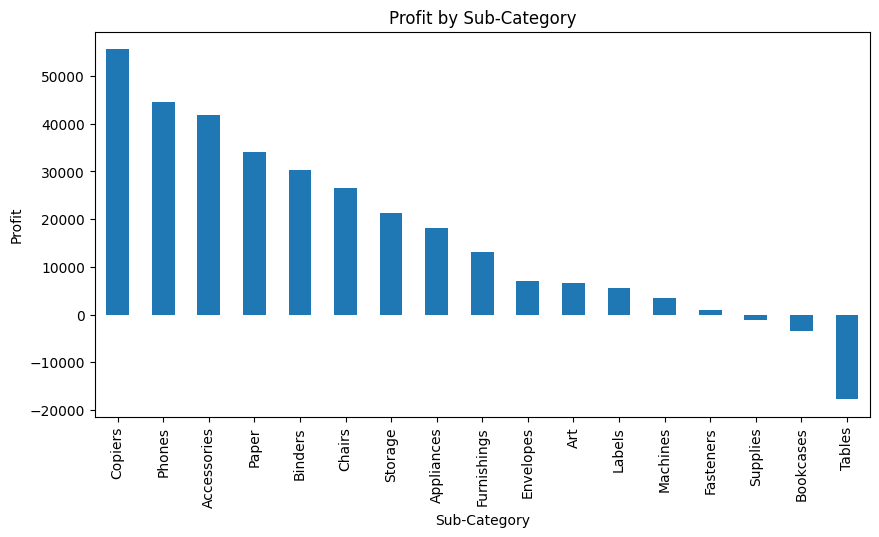

In [30]:
sub_profit.plot(kind="bar", figsize=(10,5), title="Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.show()

In [32]:
states=df.groupby("State")[["Sales","Profit"]].sum()
result=states[states["Profit"]>20000]
result=result.sort_values(by="Sales",ascending=False).head(5)
print(result)

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486
Washington  138641.2700  33402.6517
Michigan     76269.6140  24463.1876
